## EDA

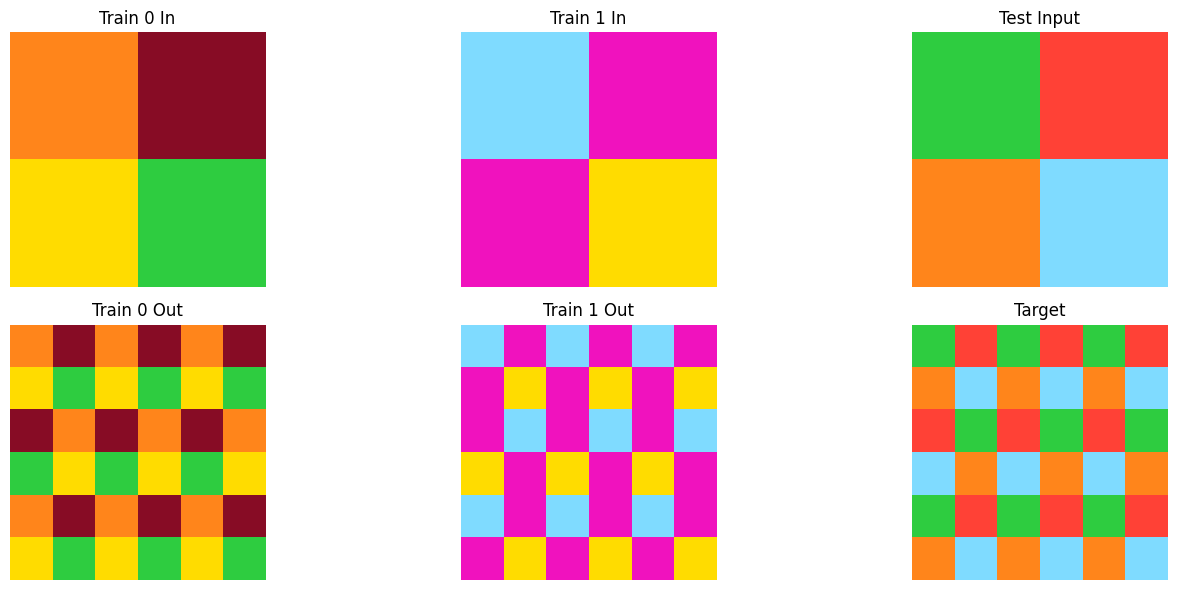

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from pathlib import Path

# ১. ডেটা লোড করার ফাংশন
def load_data(directory):
    with open(directory / 'arc-agi_training_challenges.json') as f:
        challenges = json.load(f)
    with open(directory / 'arc-agi_training_solutions.json') as f:
        solutions = json.load(f)
    return challenges, solutions

# ২. গ্রিড দেখানোর ফাংশন
def plot_task(task_id, challenges, solutions):
    task = challenges[task_id]
    sol = solutions[task_id]
    
    cmap = colors.ListedColormap(['#000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
                                  '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870C25'])
    norm = colors.BoundaryNorm(np.arange(-0.5, 10, 1), cmap.N)

    num_train = len(task['train'])
    fig, axs = plt.subplots(2, num_train + 1, figsize=(15, 6))

    for i, pair in enumerate(task['train']):
        axs[0, i].imshow(pair['input'], cmap=cmap, norm=norm)
        axs[0, i].set_title(f'Train {i} In')
        axs[0, i].axis('off')
        axs[1, i].imshow(pair['output'], cmap=cmap, norm=norm)
        axs[1, i].set_title(f'Train {i} Out')
        axs[1, i].axis('off')

    axs[0, -1].imshow(task['test'][0]['input'], cmap=cmap, norm=norm)
    axs[0, -1].set_title('Test Input')
    axs[0, -1].axis('off')
    axs[1, -1].imshow(sol[0], cmap=cmap, norm=norm)
    axs[1, -1].set_title('Target')
    axs[1, -1].axis('off')

    plt.tight_layout()
    plt.show()

# ৩. মেইন এক্সিকিউশন
# 'notebooks' থেকে এক ধাপ বাইরে গিয়ে 'data' ফোল্ডার খুঁজে বের করা
BASE_DIR = Path.cwd().parent 
data_dir = BASE_DIR / "data"

try:
    challenges, solutions = load_data(data_dir)
    # প্রথম টাস্ক (ID: 00576224) দেখা
    first_task_id = list(challenges.keys())[0]
    plot_task(first_task_id, challenges, solutions)
except Exception as e:
    print(f"Error: {e}. Make sure you are running this from the 'notebooks' folder.")